# Assignment 2 (CSI 4142) [Part 2]

# Group Information

- **Student name**: Shabrina Sharmin
- **Student Id**: 300230297
- **Group no**: A-85

# Imputation

## Description of dataset

The dataset contains information on sleep habits and their impact on exercise, productivity, moode, and stress level. The detailed description of all the features of the dataset is provided below:

* Date **(object)**: The date of data collection
* Person_ID **(int64)**:	Unique identifier for each individual
* Age	**(int64)**: Age of the person (18-60 years)
* Gender **(object)**: Male, Female, or Other
* Sleep Start Time **(float64)**:	Time when the person went to bed (in 24-hour format)
* Sleep End Time **(float64)**:	Time when the person woke up (in 24-hour format)
* Total Sleep Hours **(float64)**: Total duration of sleep (in hours)
* Sleep Quality **(int64)**: Self-reported sleep quality (scale: 1-10)
* Exercise (mins/day) **(int64)**: Minutes spent exercising per day
* Caffeine Intake (mg) **(int64)**:	Amount of caffeine consumed in mg
* Screen Time Before Bed (mins) **(int64)**:	Time spent using screens before sleeping
* Work Hours (hrs/day) **(float64)**:	Total working hours in a day
* Productivity Score **(int64)**:	Self-reported productivity score (scale: 1-10)
* Mood Score **(int64)**:	Self-reported mood score (scale: 1-10)
* Stress Level **(int64)**: Self-reported stress level (scale: 1-10)





## **Access data**

### **Local instruction for accessing dataset on kaggle:** ###
**Pre-Requisite:** User must respectively create and download their access token from https://www.kaggle.com/. If the user already has an existing kaggle token, then no need to create a new one. Just use the existing kaggle token (kaggle.json) as requested.
If the "kaggle.json" token is not under ".kaggle" folder in the home path, then place the kaggle.json in the same directoy as the notebook. The code below will copy the "kaggle.json" token to the correct location

In [1]:
# Create a kaggle configuration folder/directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json  # Adjust the permissions of the file.

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


### **Instruction for running in Google Colab** ###

Upon running the code in following section below, a prompt will pop up asking for the **'kaggle.json'** file. The user needs to click on the 'Choose file' option and navigate to the corresponding directory where the kaggle.json file should reside and choose **'kaggle.json'** file. At this point, the "kaggle.json" should be loaded to the instance of the colab.

In [2]:
from os import mkdir

## Upload kaggle API credentials to Colab
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shabrinasharmin","key":"62fe625309926cb95271b826f7908041"}'}

### **Setting up the appropriate libraries needed for the assignment** ##
Run the follwing code below to set up the appropriate libraries that are needed

In [3]:
## Install Kaggle library
!pip install -q kaggle
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install numpy

### **Download the dataset**

In [4]:
## Download the dataset 1 (sleep-cycle-and-productivity.csv)
!kaggle datasets download -d adilshamim8/sleep-cycle-and-productivity
## Unzip the dataset 1
!unzip sleep-cycle-and-productivity.zip


Dataset URL: https://www.kaggle.com/datasets/adilshamim8/sleep-cycle-and-productivity
License(s): other
  0% 0.00/155k [00:00<?, ?B/s]
100% 155k/155k [00:00<00:00, 59.3MB/s]
Archive:  sleep-cycle-and-productivity.zip
  inflating: sleep_cycle_productivity.csv  


## Imports

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime
from datetime import datetime
from datetime import date
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from scipy.stats import shapiro,skew, kurtosis, kstest
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

## Read the files

In [6]:
# read the dataset (sleep_cycle_productivity.csv)
sleep_cycle_and_Productive_data = pd.read_csv("sleep_cycle_productivity.csv")
sleep_cycle_and_Productive_data.head(20)
sleep_cycle_and_Productive_data.info()
sleep_cycle_and_Productive_data.describe()
# sleep_cycle_and_Productive_data.shape
# sleep_cycle_and_Productive_data.notnull


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           5000 non-null   object 
 1   Person_ID                      5000 non-null   int64  
 2   Age                            5000 non-null   int64  
 3   Gender                         5000 non-null   object 
 4   Sleep Start Time               5000 non-null   float64
 5   Sleep End Time                 5000 non-null   float64
 6   Total Sleep Hours              5000 non-null   float64
 7   Sleep Quality                  5000 non-null   int64  
 8   Exercise (mins/day)            5000 non-null   int64  
 9   Caffeine Intake (mg)           5000 non-null   int64  
 10  Screen Time Before Bed (mins)  5000 non-null   int64  
 11  Work Hours (hrs/day)           5000 non-null   float64
 12  Productivity Score             5000 non-null   i

,Person_ID,Age,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5527.152200,38.590600,22.005350,4.980262,6.974902,5.520800,43.962600,146.71140,91.421200,7.987873,5.644200,5.370600,5.548000
std,2595.391771,12.302799,1.157591,1.862508,1.454033,2.863845,25.798541,85.83139,52.079123,2.275734,2.872221,2.835783,2.888419
min,1000.000000,18.000000,20.000000,0.560000,4.500000,1.000000,0.000000,0.00000,0.000000,4.000067,1.000000,1.000000,1.000000
25%,3258.000000,28.000000,21.020000,3.660000,5.690000,3.000000,22.000000,73.00000,46.000000,6.032720,3.000000,3.000000,3.000000
50%,5603.000000,39.000000,22.020000,4.970000,6.960000,5.000000,44.000000,144.00000,92.000000,7.998295,6.000000,5.000000,6.000000
75%,7749.500000,49.000000,23.000000,6.310000,8.210000,8.000000,66.000000,220.00000,136.000000,9.905024,8.000000,8.000000,8.000000
max,9998.000000,59.000000,23.980000,9.420000,9.500000,10.000000,89.000000,299.00000,179.000000,11.999141,10.000000,10.000000,10.000000


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

## Missing Data and Imputations

## Type of errors

## Test 1 : Imputation of 'Sleep End Time' using MCAR missingness

### **(a) Attribute to test:**  
* Sleep End Time

### **(b) Simulate missingness:**
* Simulated Missing Completely at Random (MCAR) by randomly deleting entries from the "Sleep End Time" column.

In [7]:
# Create a copy of the original DataFrame to avoid modifying it directly
data_copy = sleep_cycle_and_Productive_data.copy()

# Set the random seed for reproducibility
np.random.seed(42)

# Define the desired missing data rate (10% in this case)
missing_rate = 0.1

# Create a boolean mask to randomly select data points to be made missing
# np.random.rand generates random numbers between 0 and 1
# The mask is True where the random number is less than the missing rate
mcar_missing_mask = np.random.rand(len(data_copy)) < missing_rate


# Introduce missing values (NaN) into the 'Sleep End Time' column
# using the mask to select the rows where data should be missing
data_copy.loc[mcar_missing_mask, 'Sleep End Time'] = np.nan
data_copy.head(20)

data_copy.isna().sum()



,0
Date,0
Person_ID,0
Age,0
Gender,0
Sleep Start Time,0
Sleep End Time,525
Total Sleep Hours,0
Sleep Quality,0
Exercise (mins/day),0
Caffeine Intake (mg),0


### **(c) Imputation**
* Random Sample Imputation was used for imputation of missing values in the column. This imputation method involves filling missing entries with random observed entries from the same column.

In [9]:
# func to impute missing values by randomly sampling observed((non-missing) values
def impute_with_random_samples(df, column_to_impute):

    # collect non-missing values from the specified column
    observed_non_missing_values = df[column_to_impute].dropna().values
    #print(len(observed_non_missing_values))

    # identify the indices of missing values in the specified column
    missing_indices = df[column_to_impute].isna()

    # randomly sample values from observed_non_missing_values to fill missing values
    # size is determined by the number of missing values in the column
    imputed_values = np.random.choice(observed_non_missing_values, size = missing_indices.sum(), replace=True)
    #print(len(imputed_values))

    # Impute the missing values using the randomly selected values
    df.loc[missing_indices, column_to_impute] = imputed_values

    return df

# apply the random imputation on the 'Sleep End Time' col
data_imputed = impute_with_random_samples(data_copy, 'Sleep End Time')

data_copy.head(20)
# Check and print the number of missing values in each column after imputation
data_imputed.isna().sum()

,0
Date,0
Person_ID,0
Age,0
Gender,0
Sleep Start Time,0
Sleep End Time,0
Total Sleep Hours,0
Sleep Quality,0
Exercise (mins/day),0
Caffeine Intake (mg),0


### **(d) Evaluation**

* In order to evaluate the imputation, Mean square Error, Mean Absolute Error, and R-Squared Error has been calculated

In [10]:
# extract the values for 'Sleep End Time' from the original dataset
actual_sleep_end_time_values = sleep_cycle_and_Productive_data['Sleep End Time']

# Calculate MSE only on the originally missing data
# thus using the mask to point to the field which were made missing; which represents by true in th musk
actual_sleep_end_time_values_at_missing = actual_sleep_end_time_values[mcar_missing_mask]
#print(len(actual_sleep_end_time_values_at_missing))

# Filter both original and imputed data to get only those indices that were originally set to missing
# thus using the mask again for selcting the filed that were changed
imputed_sleep_end_time_values = data_imputed['Sleep End Time'][mcar_missing_mask]
# print(len(imputed_sleep_end_time_values))

# Calculate the Mean Squared Error (MSE) between the actual and imputed values
mse = mean_squared_error(actual_sleep_end_time_values_at_missing, imputed_sleep_end_time_values)
print(f"Mean Squared Error (MSE): {mse}")
mae = mean_absolute_error(actual_sleep_end_time_values_at_missing, imputed_sleep_end_time_values)
print(f"Mean Absolute Error (MAE): {mae}")
r2 = r2_score(actual_sleep_end_time_values_at_missing, imputed_sleep_end_time_values)
print(f"R-squared (R2): {r2}")




Mean Squared Error (MSE): 7.129370285714285
Mean Absolute Error (MAE): 2.2061333333333333
R-squared (R2): -1.1080349004529526


Based on the output avobe of the evaluation, it seems that the random sampling imputation did not perform well. We can see that the MSE and MAE are quite high and far from zero; meanig a large error. The R-squared value is negative, which is also a crucial indication that the random sampling has introduced more variability than it was initially present in the dataset. This suggests that the random sampling imputation has failed to capture the underlying pattern of the feature "Sleep End Time".  This suggests a need to either reconsider the method of imputation by considering other methods like predictive imputation, which might better account for relationships between different variables in the data.


## Test 2: Imputation of dependent variable 'Sleep End Time' using MAR missingness

### **(a) Attribute to test:**
* Two co-related columns ('Total Sleep Hour', and 'Sleep End Time') were used for this test. Among the two
'Total Sleep Hour' was considerd as independent variable
and 'Sleep End Time' was considered as dependent variable.

* The two variable examined for correlation using heatmap. Please refer to the code section below to visualize tha heatmap.

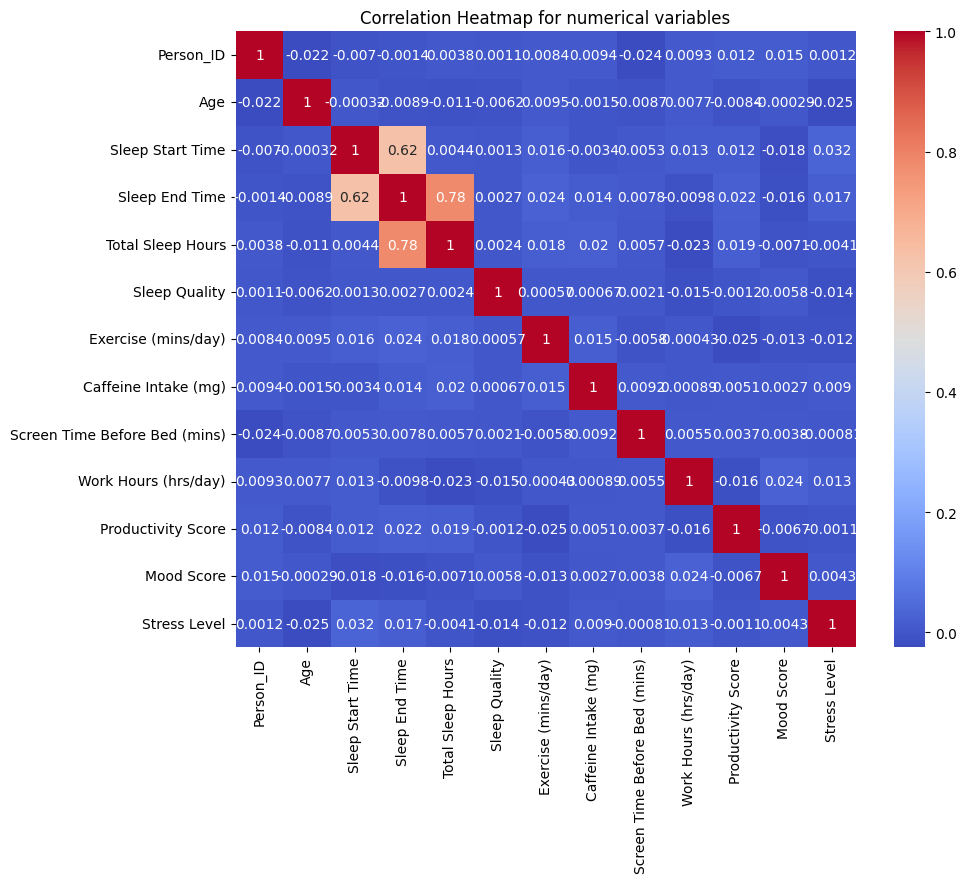

In [ ]:
# # #select the numeric variables
numeric_features_2 = sleep_cycle_and_Productive_data.select_dtypes(include=['number']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(sleep_cycle_and_Productive_data[numeric_features_2].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for numerical variables')
plt.show()

### **(b) Simulate missingness**
* Since the chosen dataset do not have any missing rows, missigness had to introduce to the dataset delibarately. Simulated Missing at Random (MAR) has been used for the removal of a portion of the values for the dependent column. The removal was done by randomly setting some of the values for the dependent variable to NaN.

In [15]:
# Create a copy of the original DataFrame to avoid modifying it directly
data_copy_2 = sleep_cycle_and_Productive_data.copy()

# Set the random seed for reproducibility
np.random.seed(42)

# Define the desired missing data rate (10% in this case)
missing_rate = 0.15

# Create a boolean mask to randomly select data points to be made missing
# np.random.rand generates random numbers between 0 and 1
# The mask is True where the random number is less than the missing rate
mar_missing_mask = np.random.rand(len(data_copy_2)) < missing_rate


# Introduce missing values (NaN) into the 'Sleep End Time' column
# using the mask to select the rows where data should be missing
data_copy_2.loc[mar_missing_mask, 'Sleep End Time'] = np.nan
data_copy_2.head(30)

data_copy_2.isna().sum()

,0
Date,0
Person_ID,0
Age,0
Gender,0
Sleep Start Time,0
Sleep End Time,775
Total Sleep Hours,0
Sleep Quality,0
Exercise (mins/day),0
Caffeine Intake (mg),0


### **(c) Imputation**
* Regression imputation  method has been used here in order to impute values for the missing cells. First, splited the data into two sets: one where "Sleep End Time" is available (to train the linear regression model) and one where "Sleep End Time" is missing (to apply the model and impute values). then,trained a linear regression model using "Total Sleep Hours" to predict "Sleep End Time" with the available data. Finally, used the trained model to predict the missing "Sleep End Time" values using the "Total Sleep Hours" in rows where "Sleep End Time" is missing.

In [16]:
# prepare data
# train model
# predict missing data using model
# evaluation

## data preparation to feed to model

# filter out the not null rows for columns 'Total Sleep Hours' and 'Sleep End Time' to be used as training data
training_data = data_copy_2.dropna(subset=['Total Sleep Hours', 'Sleep End Time'])

# divide the training data into 2 sets
# X_train-->features, y_train-->target var
X_train = training_data[['Total Sleep Hours']]
y_train = training_data['Sleep End Time']

#test data to test the trained model
# retrieving rows where 'Sleep End Time' is missing for prediction
test_data = data_copy_2[data_copy_2['Sleep End Time'].isna()]

# divide the test data into 2 sets
# X_test-->features, y_test-->target var
X_test = test_data[['Total Sleep Hours']]
#y_test = test_data['Sleep End Time']
#print(y_test)
# Model initialization
model = LinearRegression()

# Model training
model.fit(X_train, y_train)

# Model prediction for the missing Sleep End Time rows
predicted_values = model.predict(X_test)

## imputing missing values
# Replace the missing values in the original DataFrame with the predicted values
data_copy_2.loc[data_copy_2['Sleep End Time'].isna(), 'Sleep End Time'] = predicted_values

# Display the number of missing values after imputation
print("Missing 'Sleep End Time' after imputation:", data_copy_2['Sleep End Time'].isna().sum())

data_copy_2.head(20)

data_copy_2.isna().sum()



Missing 'Sleep End Time' after imputation: 0


,0
Date,0
Person_ID,0
Age,0
Gender,0
Sleep Start Time,0
Sleep End Time,0
Total Sleep Hours,0
Sleep Quality,0
Exercise (mins/day),0
Caffeine Intake (mg),0


### **(d) Evaluation**


In [17]:
#Evaluation - compare the predicted values to the actual values in the test set
#Extract the actual 'Sleep End Time' for the rows where it was originally missing (before imputation)
y_test = sleep_cycle_and_Productive_data.loc[test_data.index, 'Sleep End Time']

mse_test2_mar = mean_squared_error(y_test, predicted_values)
print(f"Mean Squared Error (MSE): {mse_test2_mar}")
mae_test2_mar = mean_absolute_error(y_test, predicted_values)
print(f"Mean Absolute Error (MAE): {mae_test2_mar}")
r2_test2_mar = r2_score(y_test, predicted_values)
print(f"R-squared (R2): {r2_test2_mar}")

Mean Squared Error (MSE): 1.4051082057459985
Mean Absolute Error (MAE): 1.0287222750022307
R-squared (R2): 0.5939410225749281


From the output of the evaluation method above, it canbe claimed that the model has moderate predictive accuracy with an R-squared of 0.594, meaning it captures a significant portion of the variance in the data. However, the errors (MSE and MAE) indicate that there is still a noticeable deviation between the predicted and actual values, suggesting room for improvement. This could involve using more relevant features, applying different modeling techniques, or tuning model parameters.

## Test 3: Imputation of variable 'Productivity Score' using MNAR missingness

### **(a) Attribute to test:**
The feature 'Productivity Score' has been used for this test.

In [18]:
col_to_impute = ['Productivity Score']

### **(b) Simulate missingness**
* Since the chosen dataset do not have any missing rows, missigness had to introduce to the dataset delibarately. Simulated Missing Not at Random (MNAR) has been used for the removal of a portion of the values for the feature 'Productivity Score'. This is MNAR because some people with exceptionaly low or high productivity may choose not to share their productivity score. Then the missigness of the feature depends on the missing data itself and hence this is MNAR. The informationThe removal was done by randomly setting some of the values for the dependent variable to NaN.


In [32]:
# Create a copy of the original DataFrame to avoid modifying it directly
data_copy_3 = sleep_cycle_and_Productive_data.copy()


# Set the random seed for reproducibility
np.random.seed(42)

# Define the desired missing data rate (10% in this case)
missing_rate = 0.20

mnar_missing_mask = (data_copy_3['Productivity Score'] < 3 ) | (data_copy_3['Productivity Score'] > 8)
data_copy_3.loc[mnar_missing_mask, 'Productivity Score'] = np.nan
data_copy_3.head(40)

data_copy_3.isna().sum()


,0
Date,0
Person_ID,0
Age,0
Gender,0
Sleep Start Time,0
Sleep End Time,0
Total Sleep Hours,0
Sleep Quality,0
Exercise (mins/day),0
Caffeine Intake (mg),0


### **(c) Imputation**

In [43]:
# Columns to train the KNN imputer
predictors = ['Exercise (mins/day)','Age','Sleep Quality', 'Work Hours (hrs/day)', 'Total Sleep Hours', 'Mood Score', 'Stress Level', 'Productivity Score']
temp_data = data_copy_3.copy()
data_subset_KNN = temp_data[predictors]


# Mask for originally missing values
missing_indices = temp_data['Productivity Score'].isna()

# KNN imputer
imputer = KNNImputer(n_neighbors=5, weights='uniform')
imputed_data = imputer.fit_transform(data_subset_KNN)

# replace the testing col 'Productivity Score' with the imputed values
temp_data['Productivity Score'] = imputed_data[:, -1]


# Evaluation
imputed_values = temp_data.loc[missing_indices, 'Productivity Score']
actual_values = sleep_cycle_and_Productive_data.loc[missing_indices, 'Productivity Score']

mse = mean_squared_error(actual_values, imputed_values)
print(f"Mean Squared Error (MSE): {mse}")
mae = mean_absolute_error(actual_values, imputed_values)
print(f"Mean Absolute Error (MAE): {mae}")
r2 = r2_score(actual_values, imputed_values)
print(f"R-squared (R2): {r2}")


Mean Squared Error (MSE): 16.369088249634324
Mean Absolute Error (MAE): 3.9388590931253047
R-squared (R2): -0.03302300937359792


### **(d) Evaluation**
From the output of the evaluation method above, it can be claimed that an MSE of 16.369 indicates that, on average, the squared differences between the predicted and actual productivity scores are quite high, suggesting a substantial variance in the errors of the predictions. Then, the MAE of approximately 3.939 means that, the predicted values deviate from the actual productivity scores by about 3.939 points. For both MSE and MAE a noticeable error in the imputation has been observed. Then, an R²  value of -0.033 (a negative value) indicates a very poor fit, suggesting that the imputed values do not represent the variance in the actual data. This typically means that the imputation model fails to capture the underlying patterns in the data, leading to predictions that do not align with the actual values.

## Conclusion ##
This report contains an analysis of the suggested types of missingness (MCAR, MAR, MNAR) and three different types of imputation applied to the dataset for the missing values. The evaluation suggests that the imputations performed were not as effective as expected as we have got significantly larger error ranges for the actual and imputed values. More robust techniques can be used to improve the evaluation score by imputing missing values that more closely predicts the missing values.

## References ##


*   https://phoenixnap.com/kb/handling-missing-data-in-python
*   https://github.com/ChangMa-ZJU/Machine-Learning-Method-Prediction-and-Generation-for-Creep-Rupture-Time/blob/main/generation_model/create_fakedata.ipynb


*   https://www.geeksforgeeks.org/handling-missing-data-with-knn-imputer/

*   https://machinelearningmastery.com/knn-imputation-for-missing-values-in-machine-learning/




